# Data Load

## Import Library

In [1]:
# 한국어 텍스트 감정 분석을 위한 필수 라이브러리들
from collections import Counter  # 카운터 자료구조
import os  # 운영체제 인터페이스
import platform  # 플랫폼 정보
import re  # 정규 표현식
import sys  # 시스템 정보
import warnings  # 경고 메시지 제어


import matplotlib.pyplot as plt  # 데이터 시각화
import numpy as np  # 수치 연산
import pandas as pd  # 데이터 처리 및 분석
import seaborn as sns  # 고급 시각화
import torch  # 딥러닝 프레임워크
import koreanize_matplotlib  # 한글 폰트 자동 설정

# 한글 폰트 설정 (koreanize_matplotlib이 자동으로 처리)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 머신러닝 관련 라이브러리
from sklearn.metrics import accuracy_score, f1_score  # 평가 지표
from sklearn.model_selection import train_test_split  # 데이터 분할

# 트랜스포머 및 BERT 관련 라이브러리
from transformers import (
    AutoModelForSequenceClassification,  # 시퀀스 분류 모델
    AutoTokenizer,  # 토크나이저
    DataCollatorWithPadding,  # 패딩 데이터 콜레이터
    set_seed,
    Trainer,  # 트레이너
    TrainingArguments,  # 훈련 설정
)

# PyTorch 데이터 처리
from torch.utils.data import Dataset  # 데이터셋 및 데이터로더

# 경고 메시지 필터링
warnings.filterwarnings("ignore")

# 라이브러리 버전 정보 출력 (재현성을 위함)
print("=== 라이브러리 버전 정보 ===")
print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"torch: {torch.__version__}")
print(f"transformers: {__import__('transformers').__version__}")
print(f"sklearn: {__import__('sklearn').__version__}")
print(f"matplotlib: {__import__('matplotlib').__version__}")
print(f"seaborn: {sns.__version__}")

# GPU 사용 가능 여부 확인
print("\n=== PyTorch GPU 지원 정보 ===")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 버전: {torch.version.cuda}")
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU: {torch.cuda.current_device()}")
    print(f"GPU 이름: {torch.cuda.get_device_name()}")
else:
    print("CPU에서 실행 중")

=== 라이브러리 버전 정보 ===
Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 2.3.3
numpy: 2.3.3
torch: 2.9.0+cu128
transformers: 4.57.1
sklearn: 1.7.2
matplotlib: 3.10.7
seaborn: 0.13.2

=== PyTorch GPU 지원 정보 ===
CUDA 사용 가능: True
CUDA 버전: 12.8
GPU 개수: 1
현재 GPU: 0
GPU 이름: NVIDIA GeForce RTX 2070


## Random Seed Configuration

In [2]:
# 랜덤 시드 설정
RANDOM_STATE = 42
set_seed(RANDOM_STATE)
print(f"랜덤 시드 {RANDOM_STATE}로 설정 완료")

랜덤 시드 42로 설정 완료


## Data Load

In [3]:
# 데이터 로드
df = pd.read_csv("../../data/raw/train.csv")

# 처음 몇 행 표시
print("\n처음 5행:")
df.head()


처음 5행:


,ID,review,label,type
0,0,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,2,augment
1,1,어느 부잣집 도련님의 철없는 행각,1,original
2,3,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,0,original
3,4,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,2,augment
4,5,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,0,original


# Data Analysis

## 1. 기본 데이터 정보


In [4]:
# 데이터셋 기본 정보
print("="*50)
print("데이터셋 기본 정보")
print("="*50)
print(f"데이터 크기: {df.shape[0]:,}행 x {df.shape[1]}열")
print(f"\n컬럼명: {list(df.columns)}")
print(f"\n데이터 타입:")
print(df.dtypes)
print(f"\n메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


데이터셋 기본 정보
데이터 크기: 279,650행 x 4열

컬럼명: ['ID', 'review', 'label', 'type']

데이터 타입:
ID         int64
review    object
label      int64
type      object
dtype: object

메모리 사용량: 122.96 MB


In [5]:
# 결측치 확인
print("\n" + "="*50)
print("결측치 정보")
print("="*50)
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    '결측치 개수': missing,
    '결측치 비율(%)': missing_percent
})
print(missing_df)

if missing.sum() == 0:
    print("\n✅ 결측치가 없습니다!")



결측치 정보
        결측치 개수  결측치 비율(%)
ID           0   0.000000
review       6   0.002146
label        0   0.000000
type         0   0.000000


In [6]:
# 샘플 데이터 확인
print("\n" + "="*50)
print("샘플 데이터 (각 레이블별 1개씩)")
print("="*50)
for label in sorted(df['label'].unique()):
    sample = df[df['label'] == label].iloc[0]
    print(f"\n[레이블 {label}]")
    print(f"리뷰: {sample['review'][:100]}...")
    print(f"타입: {sample['type']}")



샘플 데이터 (각 레이블별 1개씩)

[레이블 0]
리뷰: 왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네...
타입: original

[레이블 1]
리뷰: 어느 부잣집 도련님의 철없는 행각...
타입: original

[레이블 2]
리뷰: 이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 자신을 찾아가고, 가부장적인 사회 구조에 맞서는 모습이 너무 멋있었어요. 특히 마지막 장면에서 그...
타입: augment

[레이블 3]
리뷰: 와... 진짜 제대로 짱입니다 ㅡㅡ! 이 영화 하나로 한 주를 버틸 수 있을 것 같아요. 처음부터 끝까지 눈을 뗄 수가 없었어요. 특히 액션 장면은 진짜 소름 돋을 정도로 멋졌어요...
타입: augment


## 2. 레이블 분포 분석


In [7]:
# 레이블 분포 확인
print("="*50)
print("레이블 분포")
print("="*50)
label_counts = df['label'].value_counts().sort_index()
label_percent = (df['label'].value_counts(normalize=True).sort_index() * 100).round(2)

label_df = pd.DataFrame({
    '개수': label_counts,
    '비율(%)': label_percent
})
print(label_df)
print(f"\n총 레이블 수: {len(label_counts)}")

# 클래스 불균형 체크
max_ratio = label_counts.max() / label_counts.min()
print(f"최대/최소 비율: {max_ratio:.2f}배")
if max_ratio > 3:
    print("⚠️ 클래스 불균형이 존재합니다!")
else:
    print("✅ 클래스가 비교적 균형적입니다.")


레이블 분포
           개수  비율(%)
label               
0      114066  40.79
1       27216   9.73
2       99416  35.55
3       38952  13.93

총 레이블 수: 4
최대/최소 비율: 4.19배
⚠️ 클래스 불균형이 존재합니다!


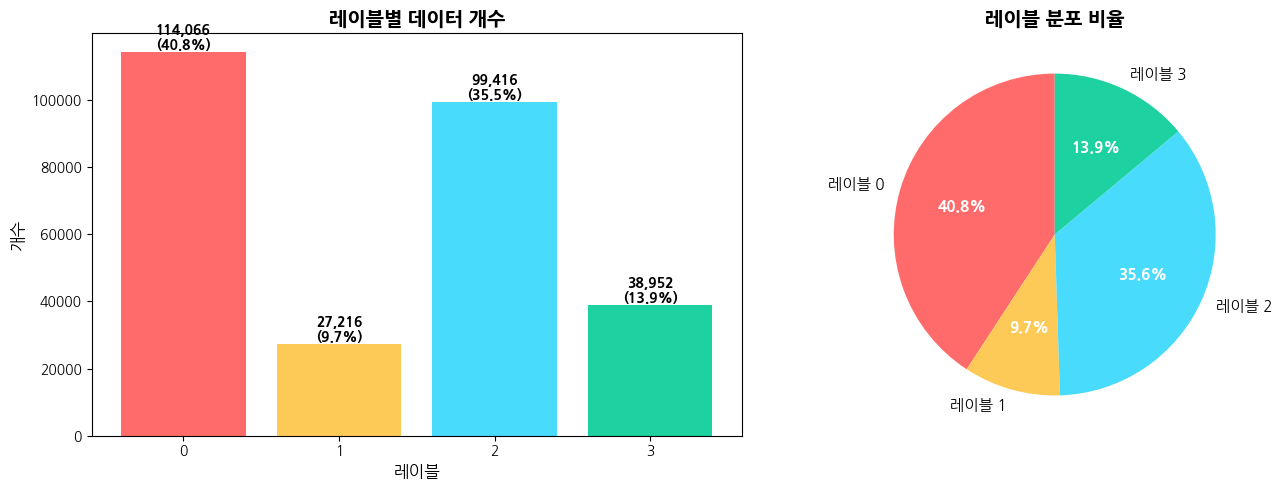

In [8]:
# 레이블 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 바 차트
ax1 = axes[0]
bars = ax1.bar(label_counts.index, label_counts.values, color=['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1'])
ax1.set_xlabel('레이블', fontsize=12)
ax1.set_ylabel('개수', fontsize=12)
ax1.set_title('레이블별 데이터 개수', fontsize=14, fontweight='bold')
ax1.set_xticks(label_counts.index)

# 막대 위에 개수 표시
for i, (idx, count) in enumerate(label_counts.items()):
    ax1.text(idx, count, f'{count:,}\n({label_percent[idx]:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 파이 차트
ax2 = axes[1]
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
wedges, texts, autotexts = ax2.pie(label_counts.values, 
                                     labels=[f'레이블 {i}' for i in label_counts.index],
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 11})
ax2.set_title('레이블 분포 비율', fontsize=14, fontweight='bold')

# autopct 텍스트 스타일
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.tight_layout()
plt.show()


## 3. 타입(Original vs Augment) 분석


In [9]:
# 타입 분포
print("="*50)
print("타입 분포")
print("="*50)
type_counts = df['type'].value_counts()
type_percent = (df['type'].value_counts(normalize=True) * 100).round(2)

type_df = pd.DataFrame({
    '개수': type_counts,
    '비율(%)': type_percent
})
print(type_df)
print(f"\nOriginal 대 Augment 비율: 1 : {type_counts['augment']/type_counts['original']:.2f}")


타입 분포
              개수  비율(%)
type                   
augment   139825   50.0
original  139825   50.0

Original 대 Augment 비율: 1 : 1.00


In [10]:
# 타입별 레이블 분포
print("\n" + "="*50)
print("타입별 레이블 분포")
print("="*50)
type_label_crosstab = pd.crosstab(df['type'], df['label'], margins=True)
print(type_label_crosstab)

# 비율로 확인
print("\n[비율 (%) - 각 타입 내에서의 레이블 비율]")
type_label_percent = pd.crosstab(df['type'], df['label'], normalize='index') * 100
print(type_label_percent.round(2))



타입별 레이블 분포
label          0      1      2      3     All
type                                         
augment    57033  13608  49708  19476  139825
original   57033  13608  49708  19476  139825
All       114066  27216  99416  38952  279650

[비율 (%) - 각 타입 내에서의 레이블 비율]
label         0     1      2      3
type                               
augment   40.79  9.73  35.55  13.93
original  40.79  9.73  35.55  13.93


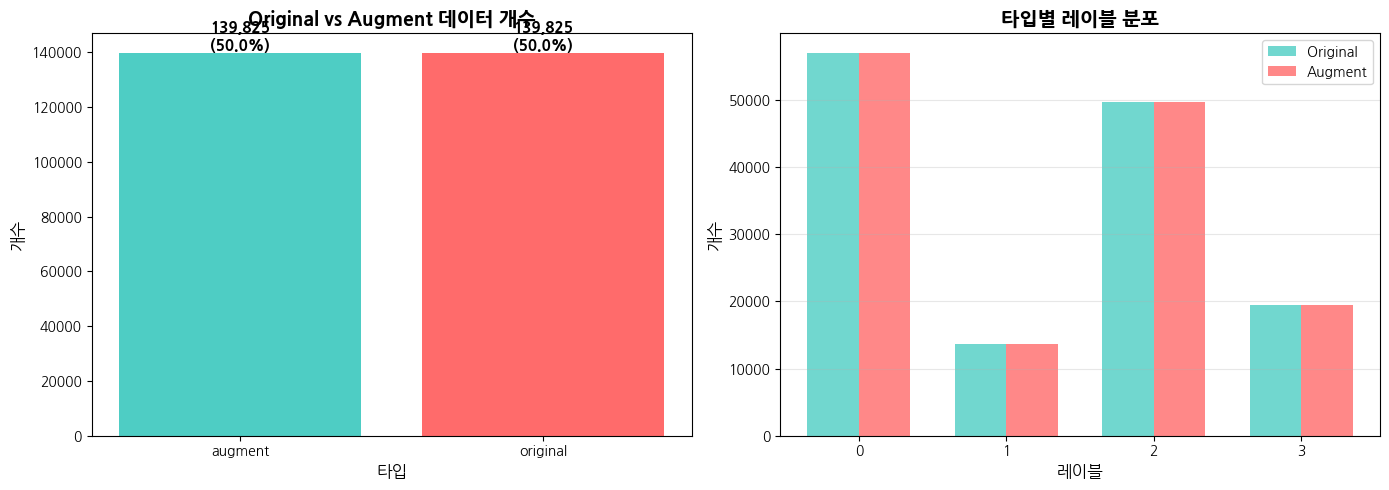

In [11]:
# 타입 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 타입별 개수
ax1 = axes[0]
bars = ax1.bar(type_counts.index, type_counts.values, color=['#4ecdc4', '#ff6b6b'])
ax1.set_xlabel('타입', fontsize=12)
ax1.set_ylabel('개수', fontsize=12)
ax1.set_title('Original vs Augment 데이터 개수', fontsize=14, fontweight='bold')

for i, (idx, count) in enumerate(type_counts.items()):
    ax1.text(i, count, f'{count:,}\n({type_percent[idx]:.1f}%)', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 타입별 레이블 분포 (그룹화된 바 차트)
ax2 = axes[1]
type_label_df = pd.crosstab(df['type'], df['label'])
x = np.arange(len(type_label_df.columns))
width = 0.35

bars1 = ax2.bar(x - width/2, type_label_df.loc['original'], width, 
                label='Original', color='#4ecdc4', alpha=0.8)
bars2 = ax2.bar(x + width/2, type_label_df.loc['augment'], width, 
                label='Augment', color='#ff6b6b', alpha=0.8)

ax2.set_xlabel('레이블', fontsize=12)
ax2.set_ylabel('개수', fontsize=12)
ax2.set_title('타입별 레이블 분포', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(type_label_df.columns)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 4. 텍스트 길이 분석


In [12]:
# 텍스트 길이 계산
df['text_length'] = df['review'].str.len()  # 글자 수
df['word_count'] = df['review'].str.split().str.len()  # 단어 수

print("="*50)
print("텍스트 길이 통계")
print("="*50)
print("\n[글자 수 통계]")
print(df['text_length'].describe())
print(f"\n[단어 수 통계]")
print(df['word_count'].describe())


텍스트 길이 통계

[글자 수 통계]
count    279644.000000
mean        158.645210
std         137.147273
min           1.000000
25%          27.000000
50%         140.000000
75%         272.000000
max        2035.000000
Name: text_length, dtype: float64

[단어 수 통계]
count    279644.000000
mean         38.759294
std          34.666607
min           1.000000
25%           6.000000
50%          33.000000
75%          68.000000
max         512.000000
Name: word_count, dtype: float64


In [13]:
# 레이블별 텍스트 길이
print("\n" + "="*50)
print("레이블별 평균 텍스트 길이")
print("="*50)

label_length_stats = df.groupby('label').agg({
    'text_length': ['mean', 'median', 'std', 'min', 'max'],
    'word_count': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

print(label_length_stats)



레이블별 평균 텍스트 길이
      text_length                             word_count                     \
             mean median     std  min     max       mean median    std  min   
label                                                                         
0          167.12  140.0  143.96  1.0  1512.0      40.78   33.0  36.51  1.0   
1          159.51  140.0  144.05  1.0  1213.0      38.58   31.0  35.60  1.0   
2          150.32  139.0  129.93  1.0  1322.0      36.76   32.0  32.65  1.0   
3          154.45  140.0  127.93  1.0  2035.0      38.08   33.0  33.09  1.0   

              
         max  
label         
0      498.0  
1      322.0  
2      333.0  
3      512.0  


In [14]:
# 타입별 텍스트 길이
print("\n" + "="*50)
print("타입별 평균 텍스트 길이")
print("="*50)

type_length_stats = df.groupby('type').agg({
    'text_length': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std']
}).round(2)

print(type_length_stats)



타입별 평균 텍스트 길이
         text_length               word_count              
                mean median    std       mean median    std
type                                                       
augment       281.99  272.0  79.45      69.91   68.0  20.49
original       35.29   27.0  29.58       7.60    6.0   6.52


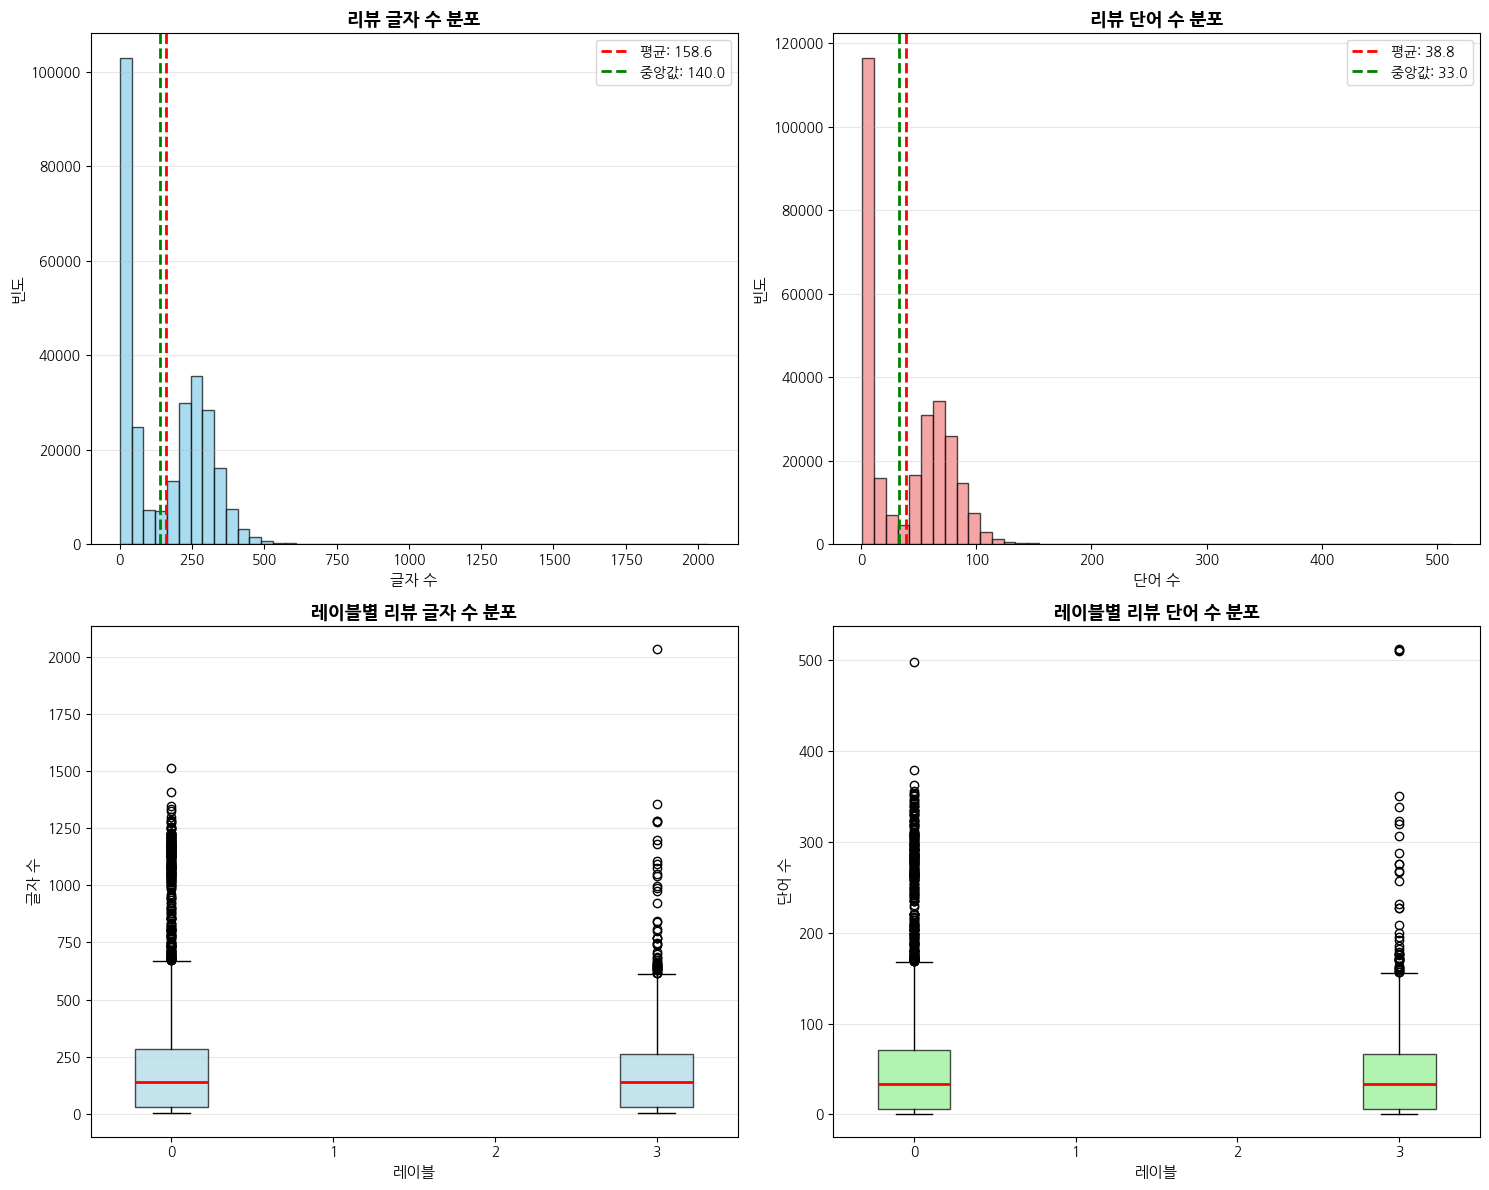

In [15]:
# 텍스트 길이 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 글자 수 히스토그램
ax1 = axes[0, 0]
ax1.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f"평균: {df['text_length'].mean():.1f}")
ax1.axvline(df['text_length'].median(), color='green', linestyle='--', linewidth=2, label=f"중앙값: {df['text_length'].median():.1f}")
ax1.set_xlabel('글자 수', fontsize=11)
ax1.set_ylabel('빈도', fontsize=11)
ax1.set_title('리뷰 글자 수 분포', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. 단어 수 히스토그램
ax2 = axes[0, 1]
ax2.hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"평균: {df['word_count'].mean():.1f}")
ax2.axvline(df['word_count'].median(), color='green', linestyle='--', linewidth=2, label=f"중앙값: {df['word_count'].median():.1f}")
ax2.set_xlabel('단어 수', fontsize=11)
ax2.set_ylabel('빈도', fontsize=11)
ax2.set_title('리뷰 단어 수 분포', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. 레이블별 글자 수 박스플롯
ax3 = axes[1, 0]
box_data = [df[df['label'] == label]['text_length'] for label in sorted(df['label'].unique())]
bp1 = ax3.boxplot(box_data, labels=sorted(df['label'].unique()), patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
ax3.set_xlabel('레이블', fontsize=11)
ax3.set_ylabel('글자 수', fontsize=11)
ax3.set_title('레이블별 리뷰 글자 수 분포', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. 레이블별 단어 수 박스플롯
ax4 = axes[1, 1]
box_data2 = [df[df['label'] == label]['word_count'] for label in sorted(df['label'].unique())]
bp2 = ax4.boxplot(box_data2, labels=sorted(df['label'].unique()), patch_artist=True,
                  boxprops=dict(facecolor='lightgreen', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
ax4.set_xlabel('레이블', fontsize=11)
ax4.set_ylabel('단어 수', fontsize=11)
ax4.set_title('레이블별 리뷰 단어 수 분포', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
# 최소/최대 길이 리뷰 샘플
print("\n" + "="*50)
print("극단적인 길이의 리뷰 샘플")
print("="*50)

# 가장 짧은 리뷰
shortest_idx = df['text_length'].idxmin()
print(f"\n[가장 짧은 리뷰 (글자 수: {df.loc[shortest_idx, 'text_length']})]")
print(f"레이블: {df.loc[shortest_idx, 'label']}")
print(f"내용: {df.loc[shortest_idx, 'review']}")

# 가장 긴 리뷰
longest_idx = df['text_length'].idxmax()
print(f"\n[가장 긴 리뷰 (글자 수: {df.loc[longest_idx, 'text_length']})]")
print(f"레이블: {df.loc[longest_idx, 'label']}")
print(f"내용: {df.loc[longest_idx, 'review'][:200]}...")  # 처음 200자만



극단적인 길이의 리뷰 샘플

[가장 짧은 리뷰 (글자 수: 1.0)]
레이블: 2
내용: 굳

[가장 긴 리뷰 (글자 수: 2035.0)]
레이블: 3
내용: 와우~~~~~진짜 대박입니다!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...


## 5. 텍스트 특성 분석


In [17]:
# 특수문자 및 이모지 분석
print("="*50)
print("특수문자 및 이모지 사용 분석")
print("="*50)

# 특수문자 개수 계산
df['exclamation_count'] = df['review'].str.count('!')  # 느낌표
df['question_count'] = df['review'].str.count('\?')  # 물음표
df['laugh_count'] = df['review'].str.count('ㅋ')  # ㅋㅋ
df['cry_count'] = df['review'].str.count('ㅠ')  # ㅠㅠ
df['dot_count'] = df['review'].str.count('\.')  # 마침표
df['tilde_count'] = df['review'].str.count('~')  # 물결표

# 이모지 개수 (간단한 패턴)
emoji_pattern = r'[😀-🙏🌀-🗿🚀-🛿✨💕❤️👍😊🎉🎊🎈🎁🎅🏼]+'
df['emoji_count'] = df['review'].str.count(emoji_pattern)

print("\n[전체 평균 특수문자 사용 횟수]")
special_chars = ['exclamation_count', 'question_count', 'laugh_count', 'cry_count', 'dot_count', 'tilde_count', 'emoji_count']
for col in special_chars:
    print(f"{col.replace('_count', '')}: {df[col].mean():.2f}")
    
# 특수문자를 사용한 리뷰 비율
print(f"\n[특수문자/이모지 사용 비율]")
print(f"느낌표 사용: {(df['exclamation_count'] > 0).sum() / len(df) * 100:.2f}%")
print(f"물음표 사용: {(df['question_count'] > 0).sum() / len(df) * 100:.2f}%")
print(f"ㅋㅋ 사용: {(df['laugh_count'] > 0).sum() / len(df) * 100:.2f}%")
print(f"ㅠㅠ 사용: {(df['cry_count'] > 0).sum() / len(df) * 100:.2f}%")
print(f"이모지 사용: {(df['emoji_count'] > 0).sum() / len(df) * 100:.2f}%")


특수문자 및 이모지 사용 분석

[전체 평균 특수문자 사용 횟수]
exclamation: 0.89
question: 0.21
laugh: 0.69
cry: 0.73
dot: 4.32
tilde: 0.13
emoji: 0.01

[특수문자/이모지 사용 비율]
느낌표 사용: 35.11%
물음표 사용: 15.38%
ㅋㅋ 사용: 7.41%
ㅠㅠ 사용: 17.99%
이모지 사용: 1.03%


In [18]:
# 레이블별 특수문자 사용 패턴
print("\n" + "="*50)
print("레이블별 특수문자 사용 패턴")
print("="*50)

label_special = df.groupby('label')[special_chars].mean().round(2)
print(label_special)



레이블별 특수문자 사용 패턴
       exclamation_count  question_count  laugh_count  cry_count  dot_count  \
label                                                                         
0                   0.27            0.31         0.70       1.13       5.66   
1                   0.27            0.25         0.57       0.88       4.45   
2                   1.24            0.13         0.61       0.23       3.10   
3                   2.24            0.12         0.95       0.74       3.38   

       tilde_count  emoji_count  
label                            
0             0.10         0.00  
1             0.08         0.00  
2             0.16         0.02  
3             0.17         0.02  


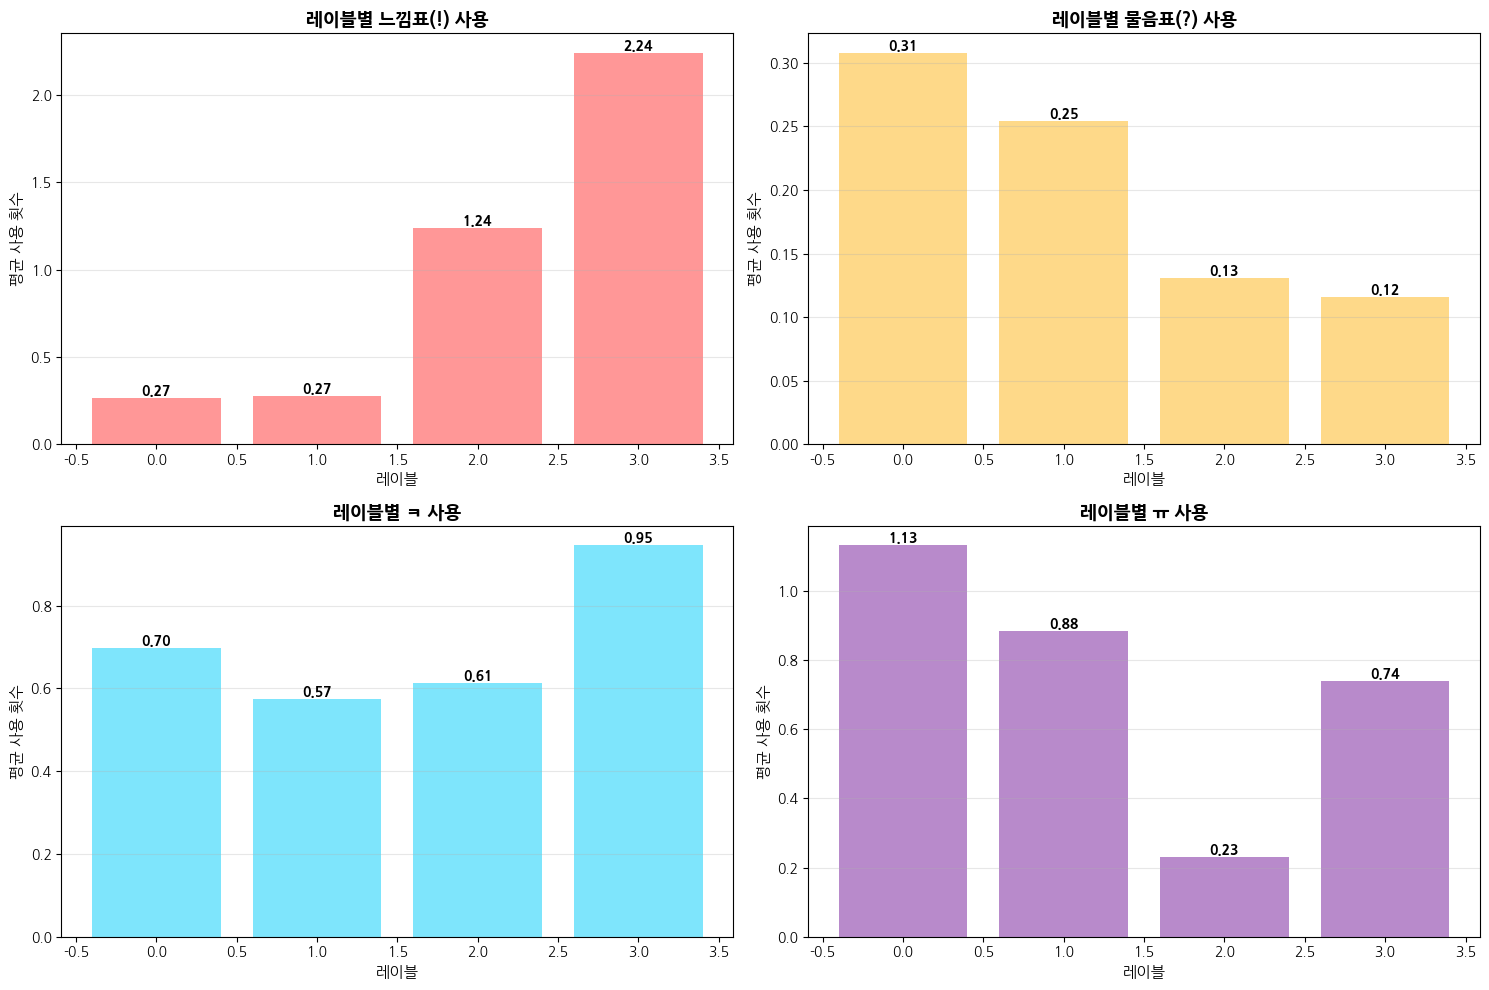

In [19]:
# 특수문자 사용 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 레이블별 느낌표 사용
ax1 = axes[0, 0]
exclaim_data = df.groupby('label')['exclamation_count'].mean()
bars1 = ax1.bar(exclaim_data.index, exclaim_data.values, color='#ff6b6b', alpha=0.7)
ax1.set_xlabel('레이블', fontsize=11)
ax1.set_ylabel('평균 사용 횟수', fontsize=11)
ax1.set_title('레이블별 느낌표(!) 사용', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(exclaim_data.values):
    ax1.text(exclaim_data.index[i], v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 2. 레이블별 물음표 사용
ax2 = axes[0, 1]
question_data = df.groupby('label')['question_count'].mean()
bars2 = ax2.bar(question_data.index, question_data.values, color='#feca57', alpha=0.7)
ax2.set_xlabel('레이블', fontsize=11)
ax2.set_ylabel('평균 사용 횟수', fontsize=11)
ax2.set_title('레이블별 물음표(?) 사용', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(question_data.values):
    ax2.text(question_data.index[i], v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 3. 레이블별 ㅋㅋ 사용
ax3 = axes[1, 0]
laugh_data = df.groupby('label')['laugh_count'].mean()
bars3 = ax3.bar(laugh_data.index, laugh_data.values, color='#48dbfb', alpha=0.7)
ax3.set_xlabel('레이블', fontsize=11)
ax3.set_ylabel('평균 사용 횟수', fontsize=11)
ax3.set_title('레이블별 ㅋ 사용', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(laugh_data.values):
    ax3.text(laugh_data.index[i], v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 4. 레이블별 ㅠㅠ 사용
ax4 = axes[1, 1]
cry_data = df.groupby('label')['cry_count'].mean()
bars4 = ax4.bar(cry_data.index, cry_data.values, color='#9b59b6', alpha=0.7)
ax4.set_xlabel('레이블', fontsize=11)
ax4.set_ylabel('평균 사용 횟수', fontsize=11)
ax4.set_title('레이블별 ㅠ 사용', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(cry_data.values):
    ax4.text(cry_data.index[i], v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. 단어/형태소 분석


In [20]:
# 전체 단어 빈도 분석 (간단한 공백 기준 분리)
print("="*50)
print("전체 단어 빈도 분석")
print("="*50)

# 모든 리뷰를 하나의 텍스트로 합치기
all_text = ' '.join(df['review'].astype(str))
words = all_text.split()

# 단어 빈도 계산
word_counter = Counter(words)
most_common_words = word_counter.most_common(30)

print("\n[가장 빈번한 단어 Top 30]")
for i, (word, count) in enumerate(most_common_words, 1):
    print(f"{i:2d}. {word:15s}: {count:6,}회")


전체 단어 빈도 분석

[가장 빈번한 단어 Top 30]
 1. 이              : 208,055회
 2. 진짜             : 195,648회
 3. 너무             : 190,145회
 4. 정말             : 139,845회
 5. 영화             : 109,066회
 6. 보는             : 104,056회
 7. 것              : 99,327회
 8. 영화는            : 93,401회
 9. 보고             : 84,336회
10. 이런             : 82,380회
11. 내내             : 76,960회
12. 영화를            : 76,614회
13. 더              : 75,270회
14. 그              : 72,099회
15. 수              : 65,495회
16. 안              : 61,378회
17. 게              : 53,927회
18. 같아요.           : 53,660회
19. 특히             : 50,657회
20. 영화가            : 49,766회
21. 배우들의           : 44,773회
22. 그냥             : 43,678회
23. ㅠㅠ             : 40,848회
24. 전혀             : 34,940회
25. 잘              : 34,849회
26. 완전             : 34,025회
27. 특히,            : 32,111회
28. 연기도            : 31,490회
29. 한              : 30,954회
30. 보면서            : 30,819회


In [21]:
# 레이블별 빈출 단어 분석
print("\n" + "="*50)
print("레이블별 빈출 단어 Top 10")
print("="*50)

for label in sorted(df['label'].unique()):
    label_text = ' '.join(df[df['label'] == label]['review'].astype(str))
    label_words = label_text.split()
    label_counter = Counter(label_words)
    label_common = label_counter.most_common(10)
    
    print(f"\n[레이블 {label}]")
    for i, (word, count) in enumerate(label_common, 1):
        print(f"  {i:2d}. {word:15s}: {count:6,}회")



레이블별 빈출 단어 Top 10

[레이블 0]
   1. 너무             : 106,022회
   2. 이              : 100,321회
   3. 진짜             : 82,753회
   4. 보는             : 55,270회
   5. 정말             : 52,786회
   6. 이런             : 52,545회
   7. 영화             : 49,829회
   8. 것              : 46,365회
   9. 안              : 45,067회
  10. 영화는            : 44,978회

[레이블 1]
   1. 너무             : 16,454회
   2. 것              : 15,056회
   3. 더              : 12,010회
   4. 이              : 11,618회
   5. 보고             : 10,499회
   6. 같아요.           :  9,412회
   7. ㅠㅠ             :  8,538회
   8. 그              :  8,487회
   9. 좀              :  7,508회
  10. 뭔가             :  7,251회

[레이블 2]
   1. 진짜             : 60,021회
   2. 이              : 58,760회
   3. 정말             : 56,003회
   4. 너무             : 45,092회
   5. 그              : 35,816회
   6. 영화             : 34,369회
   7. 수              : 33,535회
   8. 더              : 30,753회
   9. 것              : 29,714회
  10. 보는             : 29,527회

[레이블 3]
   1. 진짜     

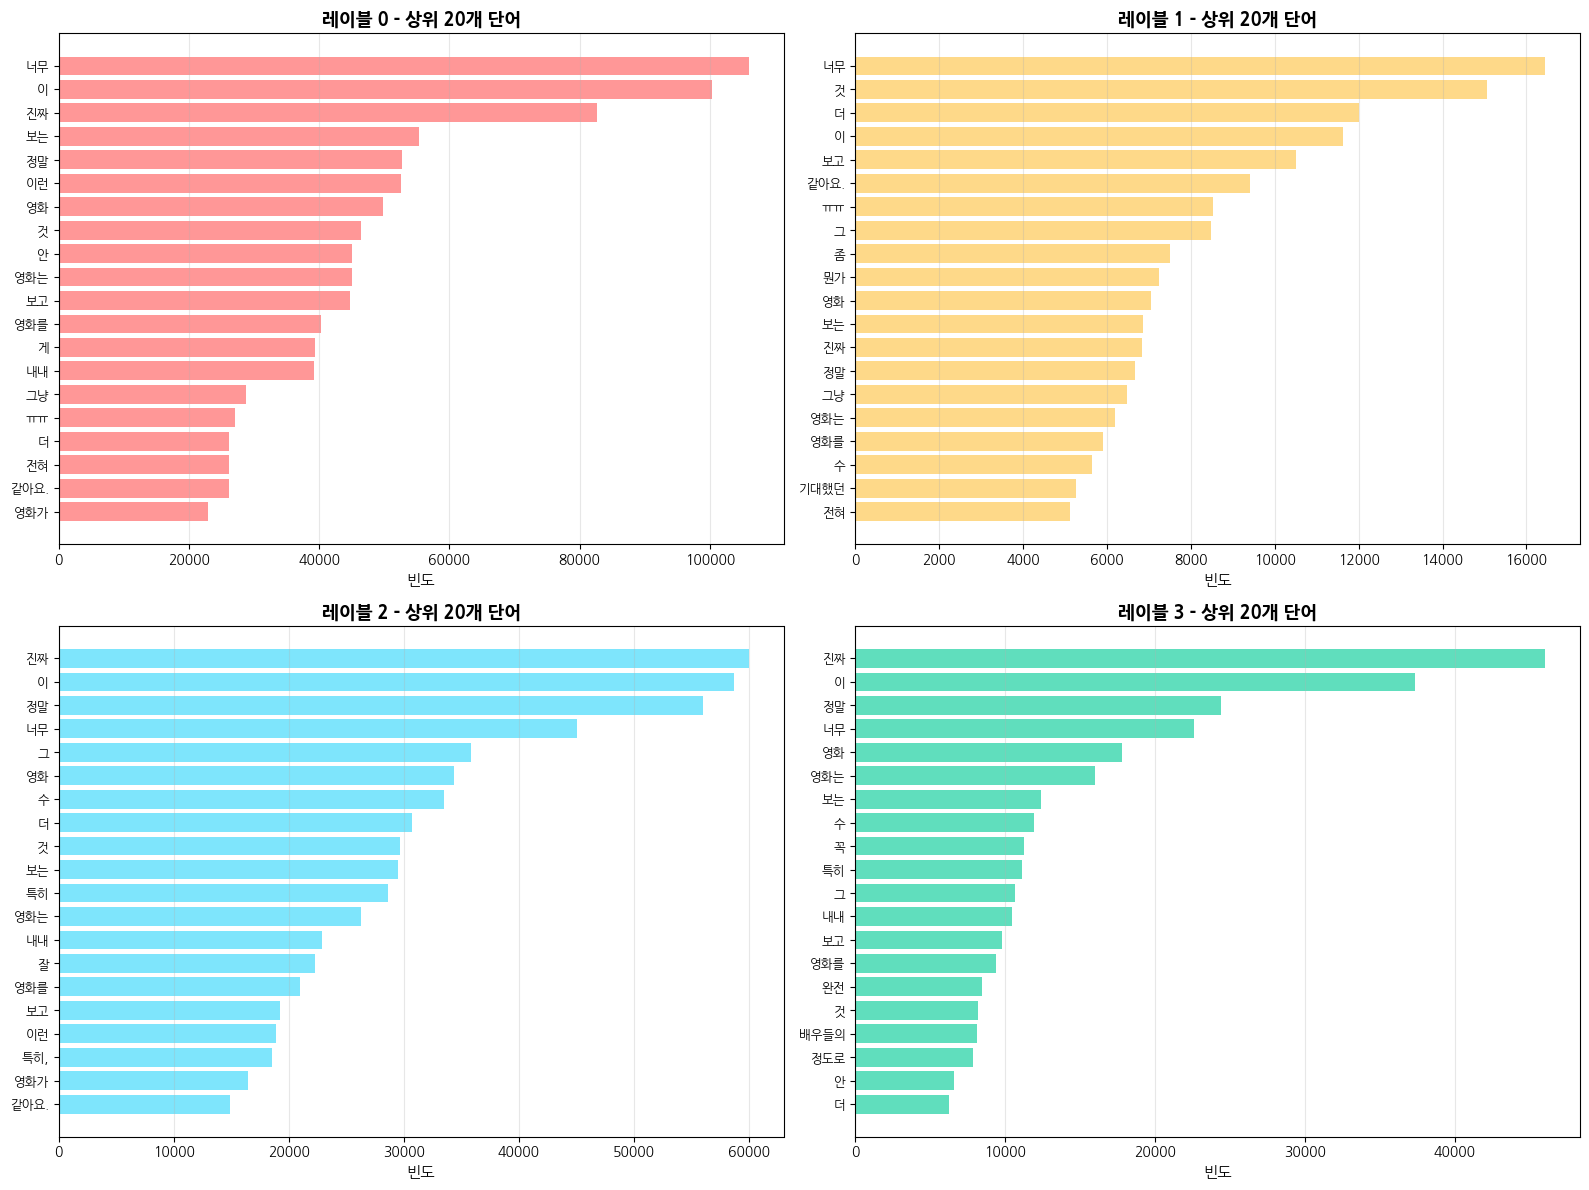

In [22]:
# 빈출 단어 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors_list = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']

for idx, label in enumerate(sorted(df['label'].unique())):
    ax = axes[idx // 2, idx % 2]
    
    # 레이블별 상위 20개 단어
    label_text = ' '.join(df[df['label'] == label]['review'].astype(str))
    label_words = label_text.split()
    label_counter = Counter(label_words)
    top_20 = label_counter.most_common(20)
    
    words_list = [word for word, count in top_20]
    counts_list = [count for word, count in top_20]
    
    # 가로 막대 그래프
    y_pos = np.arange(len(words_list))
    ax.barh(y_pos, counts_list, color=colors_list[idx], alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words_list, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('빈도', fontsize=11)
    ax.set_title(f'레이블 {label} - 상위 20개 단어', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



워드클라우드 생성


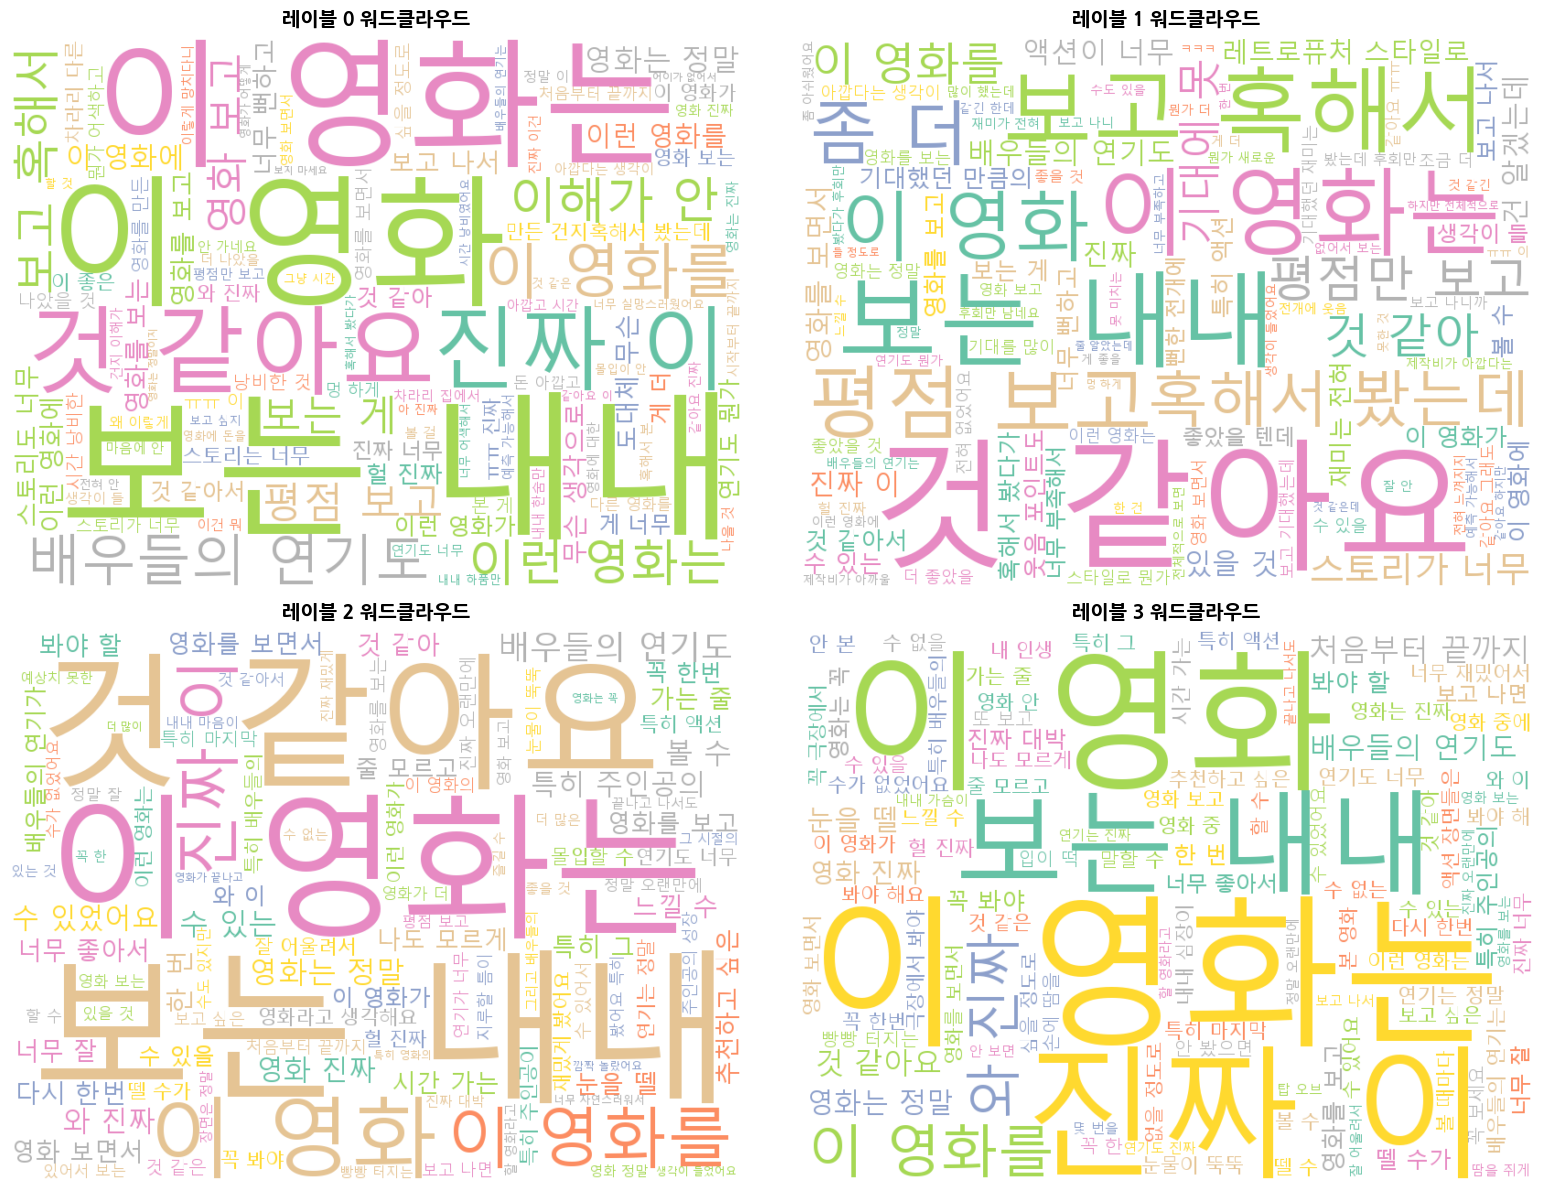


✅ 워드클라우드 생성 완료!


In [23]:
# 워드클라우드 생성 (선택사항 - wordcloud 라이브러리 필요)
try:
    from wordcloud import WordCloud
    
    print("\n" + "="*50)
    print("워드클라우드 생성")
    print("="*50)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    for idx, label in enumerate(sorted(df['label'].unique())):
        ax = axes[idx // 2, idx % 2]
        
        # 레이블별 텍스트
        label_text = ' '.join(df[df['label'] == label]['review'].astype(str))
        
        # 워드클라우드 생성
        wordcloud = WordCloud(
            font_path='C:/Windows/Fonts/malgun.ttf',  # 윈도우 한글 폰트
            width=800,
            height=600,
            background_color='white',
            max_words=100,
            relative_scaling=0.5,
            colormap='Set2'
        ).generate(label_text)
        
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'레이블 {label} 워드클라우드', fontsize=14, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()
    print("\n✅ 워드클라우드 생성 완료!")
    
except ImportError:
    print("\n⚠️ wordcloud 라이브러리가 설치되어 있지 않습니다.")
    print("설치: pip install wordcloud")


## 7. 중복 데이터 확인


In [24]:
# 중복 데이터 확인
print("="*50)
print("중복 데이터 분석")
print("="*50)

# 완전 중복 (모든 컬럼)
full_duplicates = df.duplicated().sum()
print(f"\n완전 중복 행 개수: {full_duplicates:,}개")

# 리뷰 텍스트만 중복
review_duplicates = df.duplicated(subset=['review']).sum()
print(f"리뷰 텍스트 중복 개수: {review_duplicates:,}개")
print(f"중복 비율: {review_duplicates / len(df) * 100:.2f}%")

# ID 중복 확인
id_duplicates = df.duplicated(subset=['ID']).sum()
print(f"\nID 중복 개수: {id_duplicates:,}개")

if review_duplicates > 0:
    print(f"\n⚠️ {review_duplicates:,}개의 중복 리뷰가 발견되었습니다.")
else:
    print("\n✅ 중복 리뷰가 없습니다!")


중복 데이터 분석

완전 중복 행 개수: 0개
리뷰 텍스트 중복 개수: 3,350개
중복 비율: 1.20%

ID 중복 개수: 0개

⚠️ 3,350개의 중복 리뷰가 발견되었습니다.


In [25]:
# 중복된 리뷰 샘플 확인 (있는 경우)
if review_duplicates > 0:
    print("\n" + "="*50)
    print("중복 리뷰 샘플")
    print("="*50)
    
    # 중복된 리뷰 찾기
    duplicated_reviews = df[df.duplicated(subset=['review'], keep=False)].sort_values('review')
    
    # 처음 5개의 중복 그룹 표시
    unique_dup_reviews = duplicated_reviews['review'].unique()[:5]
    
    for i, review in enumerate(unique_dup_reviews, 1):
        print(f"\n[중복 그룹 {i}]")
        dup_group = df[df['review'] == review][['ID', 'review', 'label', 'type']]
        print(dup_group.to_string(index=False))
        if i < len(unique_dup_reviews):
            print("-" * 50)



중복 리뷰 샘플

[중복 그룹 1]
    ID review  label     type
136718      !      2 original
239789      !      0 original
--------------------------------------------------

[중복 그룹 2]
    ID review  label     type
103354    -_-      0 original
170831    -_-      0 original
285674    -_-      0 original
--------------------------------------------------

[중복 그룹 3]
    ID review  label     type
 42574      0      1 original
227798      0      1 original
--------------------------------------------------

[중복 그룹 4]
    ID review  label     type
193869     0점      0 original
204111     0점      0 original
205568     0점      0 original
254826     0점      0 original
263809     0점      0 original
--------------------------------------------------

[중복 그룹 5]
    ID review  label     type
172649  0점 없나      0 original
215594  0점 없나      0 original


## 8. 이상치 및 노이즈 확인


In [26]:
# 극단적으로 짧거나 긴 리뷰 확인
print("="*50)
print("이상치 분석 - 극단적인 길이의 리뷰")
print("="*50)

# IQR 방법으로 이상치 탐지
Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nQ1 (25%): {Q1:.1f}")
print(f"Q3 (75%): {Q3:.1f}")
print(f"IQR: {IQR:.1f}")
print(f"이상치 범위: {lower_bound:.1f} 미만 또는 {upper_bound:.1f} 초과")

# 이상치 개수
outliers_short = df[df['text_length'] < lower_bound]
outliers_long = df[df['text_length'] > upper_bound]

print(f"\n너무 짧은 리뷰 (< {lower_bound:.1f}자): {len(outliers_short):,}개 ({len(outliers_short)/len(df)*100:.2f}%)")
print(f"너무 긴 리뷰 (> {upper_bound:.1f}자): {len(outliers_long):,}개 ({len(outliers_long)/len(df)*100:.2f}%)")
print(f"총 이상치: {len(outliers_short) + len(outliers_long):,}개 ({(len(outliers_short) + len(outliers_long))/len(df)*100:.2f}%)")


이상치 분석 - 극단적인 길이의 리뷰

Q1 (25%): 27.0
Q3 (75%): 272.0
IQR: 245.0
이상치 범위: -340.5 미만 또는 639.5 초과

너무 짧은 리뷰 (< -340.5자): 0개 (0.00%)
너무 긴 리뷰 (> 639.5자): 526개 (0.19%)
총 이상치: 526개 (0.19%)


In [27]:
# 매우 짧은 리뷰 샘플 (10자 이하)
print("\n" + "="*50)
print("매우 짧은 리뷰 샘플 (10자 이하)")
print("="*50)

very_short = df[df['text_length'] <= 10].sort_values('text_length')

if len(very_short) > 0:
    print(f"\n10자 이하 리뷰: {len(very_short):,}개")
    print("\n샘플 (최대 10개):")
    for idx, row in very_short.head(10).iterrows():
        print(f"  - [{row['label']}] '{row['review']}' (길이: {row['text_length']})")
else:
    print("\n10자 이하 리뷰가 없습니다.")



매우 짧은 리뷰 샘플 (10자 이하)

10자 이하 리뷰: 14,510개

샘플 (최대 10개):
  - [2] '굿' (길이: 1.0)
  - [0] '찜' (길이: 1.0)
  - [2] '굿' (길이: 1.0)
  - [2] '굿' (길이: 1.0)
  - [2] '헷' (길이: 1.0)
  - [2] '찜' (길이: 1.0)
  - [2] '짱' (길이: 1.0)
  - [2] '시' (길이: 1.0)
  - [2] '굿' (길이: 1.0)
  - [0] '웩' (길이: 1.0)


In [28]:
# 매우 긴 리뷰 샘플 (상위 1%)
print("\n" + "="*50)
print("매우 긴 리뷰 샘플 (상위 1%)")
print("="*50)

percentile_99 = df['text_length'].quantile(0.99)
print(f"\n상위 1% 기준: {percentile_99:.1f}자 이상")

very_long = df[df['text_length'] >= percentile_99].sort_values('text_length', ascending=False)
print(f"상위 1% 리뷰: {len(very_long):,}개")
print("\n샘플 (최대 5개, 처음 100자만 표시):")
for idx, row in very_long.head(5).iterrows():
    print(f"\n  - [{row['label']}] 길이: {row['text_length']}자")
    print(f"    내용: {row['review'][:100]}...")



매우 긴 리뷰 샘플 (상위 1%)

상위 1% 기준: 460.0자 이상
상위 1% 리뷰: 2,803개

샘플 (최대 5개, 처음 100자만 표시):

  - [3] 길이: 2035.0자
    내용: 와우~~~~~진짜 대박입니다!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!...

  - [0] 길이: 1512.0자
    내용: 연관인물의 연관성이 개연성을 띄어야하는데 너무 떨어져서 보는 내내 황당하고 어이가 없었어요. 이게 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 무슨 ...

  - [0] 길이: 1409.0자
    내용: 이 영화는 공주들의 삶을 그려내려고 했지만, 그냥 부유한 사람들의 사치스러운 이야기만 가득했어요. 공주들이 겪는 어려움이나 성장하는 과정은 전혀 보이지 않아서, 보는 내내 지루하고...

  - [3] 길이: 1358.0자
    내용: 기자단 평점이 이렇게 높은 영화는 난생 처음 봤습니다. 도대체 어떤 기준으로 평가를 한 건지 궁금하네요. 영화관에서 보고 온 사람들의 반응과는 완전 다른 평가에 어이가 없어서 실소...

  - [0] 길이: 1348.0자
    내용: 진짜 이 영화가 재밌다는 사람들은 무슨 생각인지 모르겠음. 내가 본 영화 중에 제일 재미없고 시간 아까웠음. 무슨 생각으로 평점 준 건지 이해가 안감. 영화를 만들려면 제대로 만들...


In [29]:
# 의미 없는 텍스트 패턴 확인
print("\n" + "="*50)
print("노이즈 패턴 확인")
print("="*50)

# 숫자만으로 이루어진 리뷰
only_numbers = df[df['review'].str.match(r'^\d+$', na=False)]
print(f"\n숫자만 있는 리뷰: {len(only_numbers):,}개")

# 특수문자가 매우 많은 리뷰 (전체의 30% 이상)
df['special_ratio'] = df['review'].apply(lambda x: len(re.findall(r'[^가-힣a-zA-Z0-9\s]', str(x))) / len(str(x)) if len(str(x)) > 0 else 0)
high_special = df[df['special_ratio'] > 0.3]
print(f"특수문자 비율 30% 이상: {len(high_special):,}개")

# 동일 문자 반복 (5회 이상)
repeated_chars = df[df['review'].str.contains(r'(.)\1{4,}', regex=True, na=False)]
print(f"동일 문자 5회 이상 반복: {len(repeated_chars):,}개")

if len(repeated_chars) > 0:
    print("\n반복 문자 샘플 (최대 5개):")
    for idx, row in repeated_chars.head(5).iterrows():
        print(f"  - [{row['label']}] {row['review'][:80]}...")



노이즈 패턴 확인

숫자만 있는 리뷰: 64개
특수문자 비율 30% 이상: 9,648개
동일 문자 5회 이상 반복: 8,606개

반복 문자 샘플 (최대 5개):
  - [1] ........글쎄....진부하기도 하고...90년대를 잘표현한건지도 모르겠고......
  - [0] 진짜 최악의 크리스마스를 보내고 싶다면 이 영화 강추합니다 ㅋㅋㅋㅋ 스토리도 완전 엉망이고, 캐릭터들도 너무 밋밋해서 보는 내내 하품만 나왔어요...
  - [0] 생방 진짜 하지 마요... 어제 방송은 진짜 최악이었음. 클라라 분량은 겁나 길고, 다른 게스트들은 거의 뻘쭘하게 앉아있기만 하고.. 대체 왜 ...
  - [3] 와... 진짜 이 영화, 스릴러의 정석이라고 해도 과언이 아님. 처음부터 끝까지 긴장감 쫄깃하게 끌고 가다가 반전의 반전을 거듭해서 영화가 끝날...
  - [2] 진짜 이 영화, 별 10개도 모자라요! 처음엔 그냥 따뜻한 드라마라고만 생각했는데, 보는 내내 가슴이 뭉클해지고, 힐링이 되는 느낌이었어요. 배...


In [30]:
# 이상치 시각화 (메모리 최적화 버전)
print("이상치 시각화 생성 중...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 박스플롯으로 이상치 표시 (이상치 점 제거)
ax1 = axes[0]
bp = ax1.boxplot([df['text_length']], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2),
                  showfliers=False)  # ✅ 이상치 점 표시 제거 (메모리 절약)
ax1.set_ylabel('글자 수', fontsize=12)
ax1.set_title('텍스트 길이 분포 (박스플롯)', fontsize=14, fontweight='bold')
ax1.set_xticklabels(['리뷰 글자 수'])
ax1.grid(axis='y', alpha=0.3)

# 통계값 표시
stats_text = f"""최소: {df['text_length'].min():.0f}
Q1: {Q1:.0f}
중앙값: {df['text_length'].median():.0f}
Q3: {Q3:.0f}
최대: {df['text_length'].max():.0f}"""

ax1.text(1.35, df['text_length'].median(), stats_text, 
         fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. 히스토그램 + 이상치 범위 표시 (최적화)
ax2 = axes[1]
ax2.hist(df['text_length'], bins=50, color='skyblue', alpha=0.7)
ax2.axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'하한: {lower_bound:.1f}')
ax2.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'상한: {upper_bound:.1f}')
ax2.axvline(df['text_length'].median(), color='green', linestyle='--', linewidth=2, label=f"중앙값: {df['text_length'].median():.1f}")
ax2.set_xlabel('글자 수', fontsize=12)
ax2.set_ylabel('빈도', fontsize=12)
ax2.set_title('텍스트 길이 분포 및 이상치 범위', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ 시각화 완료!")

# 이상치 정보 출력
print(f"\n📊 이상치 통계:")
print(f"  • 전체 데이터: {len(df):,}개")
print(f"  • 이상치 (outliers): {len(outliers_short) + len(outliers_long):,}개 ({(len(outliers_short) + len(outliers_long))/len(df)*100:.2f}%)")
print(f"  • 짧은 이상치: {len(outliers_short):,}개")
print(f"  • 긴 이상치: {len(outliers_long):,}개")

이상치 시각화 생성 중...


✅ 시각화 완료!

📊 이상치 통계:
  • 전체 데이터: 279,650개
  • 이상치 (outliers): 526개 (0.19%)
  • 짧은 이상치: 0개
  • 긴 이상치: 526개


## 9. 종합 요약


In [31]:
# EDA 종합 요약
print("="*70)
print(" "*25 + "EDA 종합 요약")
print("="*70)

print("\n📊 데이터셋 기본 정보")
print(f"  • 총 데이터 수: {len(df):,}개")
print(f"  • 컬럼 수: {df.shape[1]}개")
print(f"  • 결측치: {'없음' if df.isnull().sum().sum() == 0 else '있음'}")

print("\n🏷️ 레이블 분포")
for label in sorted(df['label'].unique()):
    count = len(df[df['label'] == label])
    pct = count / len(df) * 100
    print(f"  • 레이블 {label}: {count:,}개 ({pct:.1f}%)")

print("\n📝 타입 분포")
for type_name in df['type'].unique():
    count = len(df[df['type'] == type_name])
    pct = count / len(df) * 100
    print(f"  • {type_name}: {count:,}개 ({pct:.1f}%)")

print("\n📏 텍스트 길이 통계")
print(f"  • 평균 글자 수: {df['text_length'].mean():.1f}자")
print(f"  • 중앙값 글자 수: {df['text_length'].median():.1f}자")
print(f"  • 최소 글자 수: {df['text_length'].min()}자")
print(f"  • 최대 글자 수: {df['text_length'].max()}자")
print(f"  • 평균 단어 수: {df['word_count'].mean():.1f}개")

print("\n💬 특수문자 사용")
print(f"  • 느낌표(!) 사용: {(df['exclamation_count'] > 0).sum() / len(df) * 100:.1f}%")
print(f"  • 물음표(?) 사용: {(df['question_count'] > 0).sum() / len(df) * 100:.1f}%")
print(f"  • ㅋㅋ 사용: {(df['laugh_count'] > 0).sum() / len(df) * 100:.1f}%")
print(f"  • ㅠㅠ 사용: {(df['cry_count'] > 0).sum() / len(df) * 100:.1f}%")

print("\n🔄 중복 데이터")
print(f"  • 리뷰 텍스트 중복: {review_duplicates:,}개 ({review_duplicates/len(df)*100:.2f}%)")

print("\n⚠️ 이상치")
print(f"  • 너무 짧은 리뷰 (< {lower_bound:.1f}자): {len(outliers_short):,}개")
print(f"  • 너무 긴 리뷰 (> {upper_bound:.1f}자): {len(outliers_long):,}개")
print(f"  • 10자 이하 리뷰: {len(very_short):,}개")
print(f"  • 상위 1% 긴 리뷰 기준: {percentile_99:.1f}자 이상")

print("\n🔍 노이즈")
print(f"  • 숫자만 있는 리뷰: {len(only_numbers):,}개")
print(f"  • 특수문자 비율 30% 이상: {len(high_special):,}개")
print(f"  • 동일 문자 5회 이상 반복: {len(repeated_chars):,}개")

print("\n" + "="*70)
print("EDA 완료! 위 분석 결과를 바탕으로 전처리 및 모델링 전략을 수립하세요.")
print("="*70)


                         EDA 종합 요약

📊 데이터셋 기본 정보
  • 총 데이터 수: 279,650개
  • 컬럼 수: 14개
  • 결측치: 있음

🏷️ 레이블 분포
  • 레이블 0: 114,066개 (40.8%)
  • 레이블 1: 27,216개 (9.7%)
  • 레이블 2: 99,416개 (35.6%)
  • 레이블 3: 38,952개 (13.9%)

📝 타입 분포
  • augment: 139,825개 (50.0%)
  • original: 139,825개 (50.0%)

📏 텍스트 길이 통계
  • 평균 글자 수: 158.6자
  • 중앙값 글자 수: 140.0자
  • 최소 글자 수: 1.0자
  • 최대 글자 수: 2035.0자
  • 평균 단어 수: 38.8개

💬 특수문자 사용
  • 느낌표(!) 사용: 35.1%
  • 물음표(?) 사용: 15.4%
  • ㅋㅋ 사용: 7.4%
  • ㅠㅠ 사용: 18.0%

🔄 중복 데이터
  • 리뷰 텍스트 중복: 3,350개 (1.20%)

⚠️ 이상치
  • 너무 짧은 리뷰 (< -340.5자): 0개
  • 너무 긴 리뷰 (> 639.5자): 526개
  • 10자 이하 리뷰: 14,510개
  • 상위 1% 긴 리뷰 기준: 460.0자 이상

🔍 노이즈
  • 숫자만 있는 리뷰: 64개
  • 특수문자 비율 30% 이상: 9,648개
  • 동일 문자 5회 이상 반복: 8,606개

EDA 완료! 위 분석 결과를 바탕으로 전처리 및 모델링 전략을 수립하세요.
